In [8]:
import os
from PIL import Image
import pandas as pd
import numpy as np


In [11]:
# Define the folder path
folder_path = r'F:\yujun\projects\AI_IAPS\RDM\gist_txt'

NA_names = []
AI_names = []
# Initialize lists to store file contents
NA_gist = []
AI_gist = []

# Read the filenames and categorize them based on containing '_'
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt"):
        file_path = os.path.join(folder_path, file_name)
        try:
            # Read the contents of the txt file
            file_contents = np.loadtxt(file_path)
            
            # Categorize based on the presence of '_'
            if '_' in file_name:
                AI_gist.append(file_contents)
                AI_names.append(file_name)
            else:
                NA_gist.append(file_contents)
                NA_names.append(file_name)
        except Exception as e:
            print(f"Error reading {file_name}: {e}")

In [10]:
AI_df = pd.DataFrame(AI_gist)
NA_df = pd.DataFrame(NA_gist)
print(AI_df.shape, NA_df.shape)


(60, 512) (60, 512)


In [34]:
# Calculate the correlation between each row in AI_df and NA_df across 512 features
correlation_values = [np.corrcoef(AI_df.iloc[i], NA_df.iloc[i])[0, 1] for i in range(60)]

# Calculate the average correlation value across the 60 images
average_correlation = np.mean(correlation_values)

average_correlation

0.5500135309180527

In [12]:
AI_names

['gist1205_2.jpg.txt',
 'gist1270_0.jpg.txt',
 'gist1419_2.jpg.txt',
 'gist1510_2.jpg.txt',
 'gist1604_2.jpg.txt',
 'gist1640_0.jpg.txt',
 'gist2010_2.jpg.txt',
 'gist2045_2.jpg.txt',
 'gist2092_1.jpg.txt',
 'gist2110_1.jpg.txt',
 'gist2300_0.jpg.txt',
 'gist2314_0.jpg.txt',
 'gist2446_2.jpg.txt',
 'gist2484_1.jpg.txt',
 'gist2499_1.jpg.txt',
 'gist2540_2.jpg.txt',
 'gist2550_0.jpg.txt',
 'gist2580_1.jpg.txt',
 'gist2850_1.jpg.txt',
 'gist2900.1_1.jpg.txt',
 'gist3016_1.jpg.txt',
 'gist3051_0.jpg.txt',
 'gist3101_0.jpg.txt',
 'gist3230_0.jpg.txt',
 'gist4001_2.jpg.txt',
 'gist4150_0.jpg.txt',
 'gist4180_0.jpg.txt',
 'gist4210_0.jpg.txt',
 'gist4232_0.jpg.txt',
 'gist4505_1.jpg.txt',
 'gist4534_2.jpg.txt',
 'gist4574_2.jpg.txt',
 'gist4597_2.jpg.txt',
 'gist4601_0.jpg.txt',
 'gist4604_0.jpg.txt',
 'gist4628_1.jpg.txt',
 'gist4770_0.jpg.txt',
 'gist5395_2.jpg.txt',
 'gist5455_2.jpg.txt',
 'gist5470_2.jpg.txt',
 'gist5551_1.jpg.txt',
 'gist5600_0.jpg.txt',
 'gist5661_0.jpg.txt',
 'gist566

In [13]:
NA_names

['gist1205.jpg.txt',
 'gist1270.jpg.txt',
 'gist1419.jpg.txt',
 'gist1510.jpg.txt',
 'gist1604.jpg.txt',
 'gist1640.jpg.txt',
 'gist2010.jpg.txt',
 'gist2045.jpg.txt',
 'gist2092.jpg.txt',
 'gist2110.jpg.txt',
 'gist2300.jpg.txt',
 'gist2314.jpg.txt',
 'gist2446.jpg.txt',
 'gist2484.jpg.txt',
 'gist2499.jpg.txt',
 'gist2540.jpg.txt',
 'gist2550.jpg.txt',
 'gist2580.jpg.txt',
 'gist2850.jpg.txt',
 'gist2900.1.jpg.txt',
 'gist3016.jpg.txt',
 'gist3051.jpg.txt',
 'gist3101.jpg.txt',
 'gist3230.jpg.txt',
 'gist4001.jpg.txt',
 'gist4150.jpg.txt',
 'gist4180.jpg.txt',
 'gist4210.jpg.txt',
 'gist4232.jpg.txt',
 'gist4505.jpg.txt',
 'gist4534.jpg.txt',
 'gist4574.jpg.txt',
 'gist4597.jpg.txt',
 'gist4601.jpg.txt',
 'gist4604.jpg.txt',
 'gist4628.jpg.txt',
 'gist4770.jpg.txt',
 'gist5395.jpg.txt',
 'gist5455.jpg.txt',
 'gist5470.jpg.txt',
 'gist5551.jpg.txt',
 'gist5600.jpg.txt',
 'gist5661.jpg.txt',
 'gist5665.jpg.txt',
 'gist5779.jpg.txt',
 'gist6211.jpg.txt',
 'gist6940.jpg.txt',
 'gist7186.

In [14]:
# Calculate RDM for AI_df
AI_rdm = 1 - 0.5 * (AI_df.T.corr(method="pearson") + 1)

# Calculate RDM for NA_df
NA_rdm = 1 - 0.5 * (NA_df.T.corr(method="pearson") + 1)

# Show the shapes of the RDMs
AI_rdm_shape = AI_rdm.shape
NA_rdm_shape = NA_rdm.shape

AI_rdm_shape, NA_rdm_shape

((60, 60), (60, 60))

In [ ]:
# Calculate RDM for AI_df
AI_rdm = 1 - 0.5 * (AI_df.T.corr(method="pearson") + 1)

# Calculate RDM for NA_df
NA_rdm = 1 - 0.5 * (NA_df.T.corr(method="pearson") + 1)

# Show the shapes of the RDMs
AI_rdm_shape = AI_rdm.shape
NA_rdm_shape = NA_rdm.shape

AI_rdm_shape, NA_rdm_shape

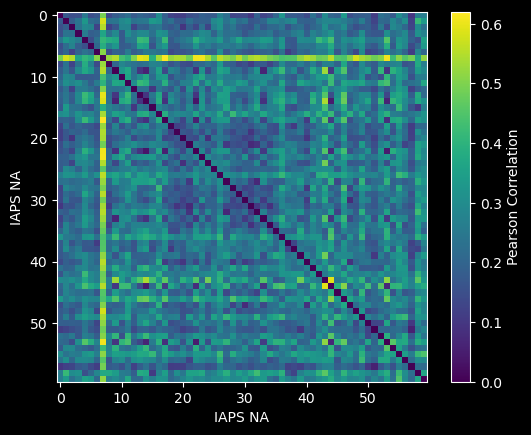

In [15]:
# import libraries
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(NA_rdm)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS NA')
plt.ylabel('IAPS NA')
bar.set_label('Pearson Correlation')
plt.show()

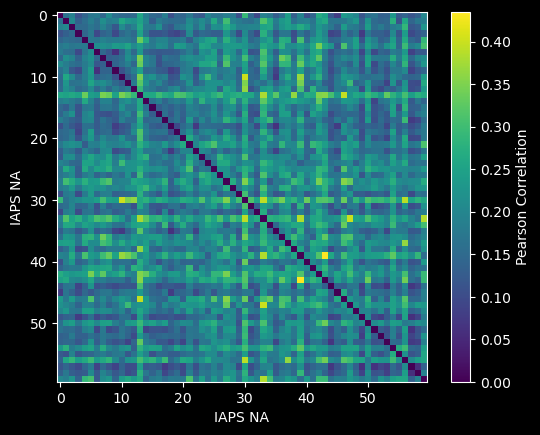

In [16]:
# import libraries
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(AI_rdm)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS NA')
plt.ylabel('IAPS NA')
bar.set_label('Pearson Correlation')
plt.show()

In [17]:
# Extract the upper triangle (excluding the diagonal) for both RDMs
def upper_triangle_values(rdm):
    return rdm.where(np.triu(np.ones(rdm.shape), k=1).astype(bool)).stack()

AI_rdm_upper = upper_triangle_values(AI_rdm)
NA_rdm_upper = upper_triangle_values(NA_rdm)

# Calculate the correlation between the upper triangle values of both RDMs
rdm_correlation = AI_rdm_upper.corr(NA_rdm_upper)

rdm_correlation

0.09012345926239558

In [18]:
AI_rdm_upper.shape

(1770,)

In [19]:
NA_rdm_upper.shape

(1770,)

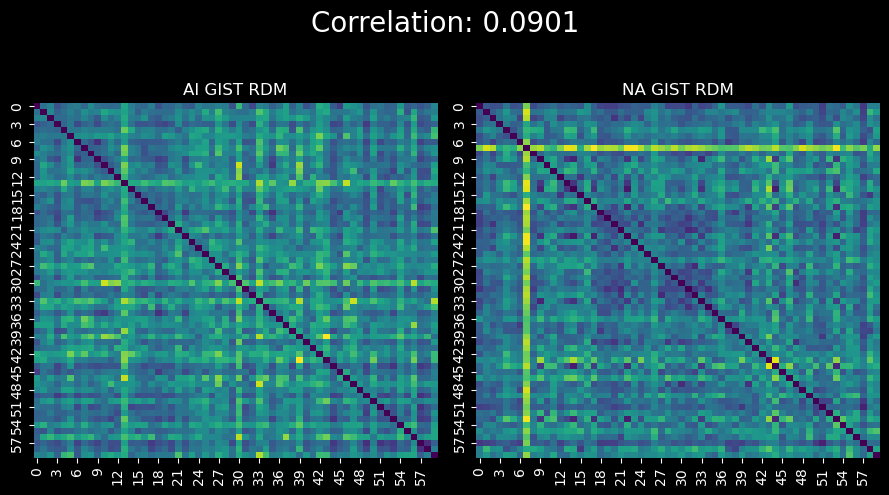

In [31]:
import seaborn as sns
# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

# Plot AI RDM
sns.heatmap(AI_rdm, ax=axes[0], cmap="viridis", cbar=False)
axes[0].set_title("AI GIST RDM")

# Plot NA RDM
sns.heatmap(NA_rdm, ax=axes[1], cmap="viridis", cbar=False)
axes[1].set_title("NA GIST RDM")


# Set the main title as the correlation value
fig.suptitle(f"Correlation: {rdm_correlation:.4f}", fontsize=20)

# Show the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()